In [2]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

In [20]:
mnist=tf.keras.datasets.mnist
(x_train,y_train),(x_test,y_test)=mnist.load_data()
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)
input_shape = (28, 28, 1)
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255.0
x_test /= 255.0
model=tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(100, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5)
model.evaluate(x_test, y_test)
model.save('recog.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 66s 35ms/step - accuracy: 0.9599 - loss: 0.1287
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 35ms/step - accuracy: 0.9871 - loss: 0.0413
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 34ms/step - accuracy: 0.9911 - loss: 0.0280
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 35ms/step - accuracy: 0.9939 - loss: 0.0190
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 35ms/step - accuracy: 0.9952 - loss: 0.0141
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9900 - loss: 0.0334


In [9]:
loaded_model = tf.keras.models.load_model('recog.keras')

loss, accuracy = loaded_model.evaluate(x_test, y_test)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9910 - loss: 0.0307
Test Loss: 0.0307
Test Accuracy: 0.9910


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2


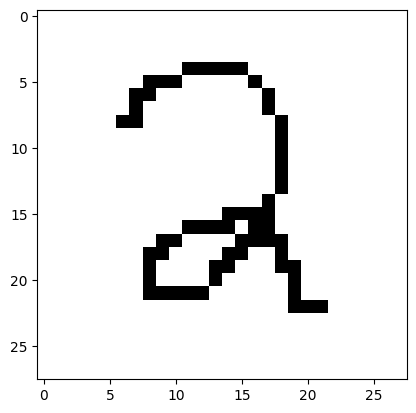

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1


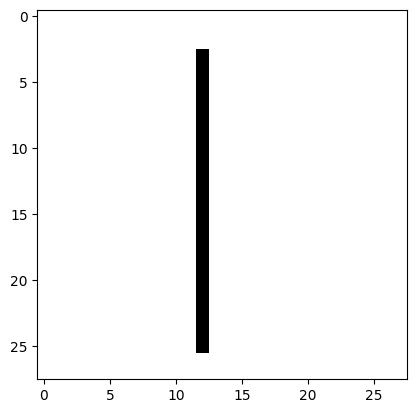

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
4


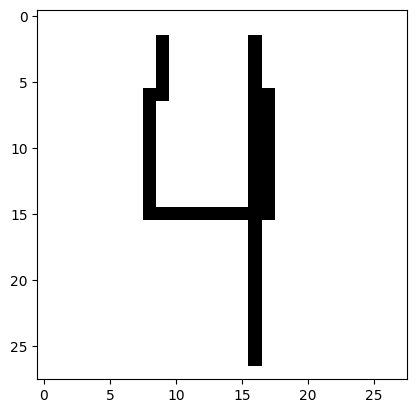

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
3


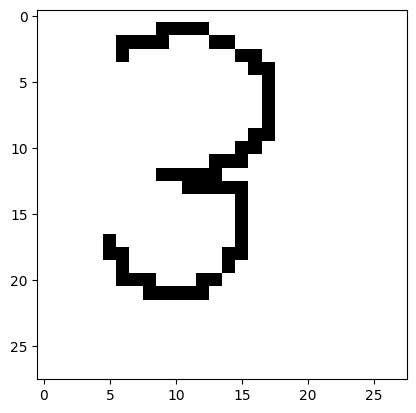

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
5


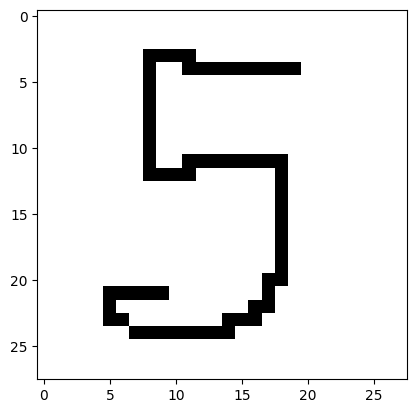

In [15]:
c=1
while os.path.exists(f'digits/digit{c}.png'):
  try:
    img=cv2.imread(f'digits/digit{c}.png')[:,:,0]
    img=np.invert(cv2.resize(img,(28,28)))
    plt.imshow(img,cmap=plt.cm.binary)
    # print("The Digit is maybe ",end=" ")
    print(np.argmax(loaded_model.predict(img.reshape(1,28,28,1))))
    plt.show()
  except:
    print(f"Error processing digit{c}.png")
  finally:
    c+=1